In [401]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report,confusion_matrix

In [402]:
df = pd.read_csv('diabetes.csv')

In [403]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [404]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [405]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

C:\Users\sanja\AppData\Local\Temp\ipykernel_27072\819619937.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Outcome", data=df,palette='cool')


<Axes: xlabel='Outcome', ylabel='count'>

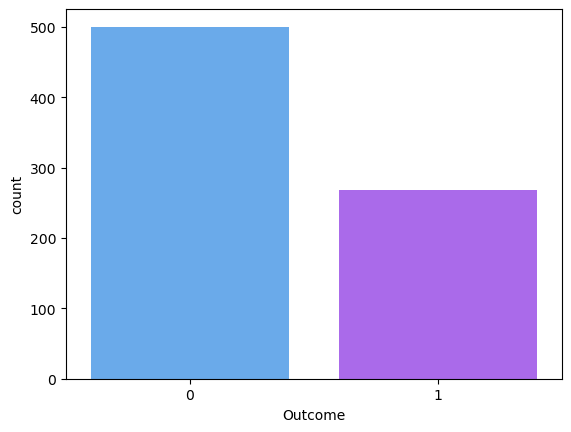

In [406]:
sns.countplot(x="Outcome", data=df,palette='cool')

In [407]:
df.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


In [408]:
x = df.drop(['Outcome'],axis=1)
y = df['Outcome']
print(x)
print(y)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [409]:
st = StandardScaler()

In [410]:
st.fit(x)

StandardScaler()

In [411]:
st_data = st.transform(x)
st_data

array([[ 0.63994726,  0.84832379,  0.14964075, ...,  0.20401277,
         0.46849198,  1.4259954 ],
       [-0.84488505, -1.12339636, -0.16054575, ..., -0.68442195,
        -0.36506078, -0.19067191],
       [ 1.23388019,  1.94372388, -0.26394125, ..., -1.10325546,
         0.60439732, -0.10558415],
       ...,
       [ 0.3429808 ,  0.00330087,  0.14964075, ..., -0.73518964,
        -0.68519336, -0.27575966],
       [-0.84488505,  0.1597866 , -0.47073225, ..., -0.24020459,
        -0.37110101,  1.17073215],
       [-0.84488505, -0.8730192 ,  0.04624525, ..., -0.20212881,
        -0.47378505, -0.87137393]])

In [412]:
x = st_data


In [413]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state = 2)

In [414]:
print(x.shape,x_train.shape,x_test.shape)

(768, 8) (614, 8) (154, 8)


In [415]:
classifier = svm.SVC(kernel='linear')

In [416]:
classifier.fit(x_train,y_train)


SVC(kernel='linear')

In [417]:
y_pred= classifier.predict(x_test)
score=accuracy_score(y_pred,y_test)
print(score)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

0.7662337662337663
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       109
           1       0.63      0.49      0.55        45

    accuracy                           0.77       154
   macro avg       0.72      0.68      0.70       154
weighted avg       0.75      0.77      0.76       154

[[96 13]
 [23 22]]


In [418]:
from sklearn.model_selection import GridSearchCV
class_weight=[{0:w,1:y} for w in [1,1.1,0.9,1.2,0.8] for y in [1,1.1,0.9,1.2,0.8]]
# defining parameter range
param_grid = {'C': [0.1, 1, 10, 100, 1000],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
              'kernel': ['rbf','polynomial','sigmoid'],'class_weight':class_weight}

In [419]:
from sklearn.svm import SVC
grid=GridSearchCV(SVC(),param_grid=param_grid,refit=True,cv=5,verbose=1)

In [420]:
grid.fit(x_train,y_train)

Fitting 5 folds for each of 1875 candidates, totalling 9375 fits


c:\Users\sanja\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:378: FitFailedWarning: 
3125 fits failed out of a total of 9375.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3125 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\sanja\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\sanja\anaconda3\Lib\site-packages\sklearn\svm\_base.py", line 180, in fit
    self._validate_params()
  File "c:\Users\sanja\anaconda3\Lib\site-packages\sklearn\base.py", line 600, in _validate_params
    validate_parameter_constraints(
  File "c:\Users\sanja\anaconda3\Lib\site-packages

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 1.1},
                                          {0: 1, 1: 0.9}, {0: 1, 1: 1.2},
                                          {0: 1, 1: 0.8}, {0: 1.1, 1: 1},
                                          {0: 1.1, 1: 1.1}, {0: 1.1, 1: 0.9},
                                          {0: 1.1, 1: 1.2}, {0: 1.1, 1: 0.8},
                                          {0: 0.9, 1: 1}, {0: 0.9, 1: 1.1},
                                          {0: 0.9, 1: 0.9}, {0: 0.9, 1: 1.2},
                                          {0: 0.9, 1: 0.8}, {0: 1.2, 1: 1},
                                          {0: 1.2, 1: 1.1}, {0: 1.2, 1: 0.9},
                                          {0: 1.2, 1: 1.2}, {0: 1.2, 1: 0.8},
                                          {0: 0.8, 1: 1}, {0: 0.8, 1: 1.1},
                                          {0: 0.8, 1: 0.9}, {0: 0.8, 1: 1.2},
                                          {0: 0.8, 1: 0.8}],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf', 'polynomial', 'sigmoid']},
             verbose=1)

In [421]:
grid.best_params_

{'C': 1, 'class_weight': {0: 0.9, 1: 0.9}, 'gamma': 0.01, 'kernel': 'rbf'}

In [422]:
y_pred= grid.predict(x_test)
score=accuracy_score(y_pred,y_test)
print(score)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

0.7662337662337663
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       109
           1       0.64      0.47      0.54        45

    accuracy                           0.77       154
   macro avg       0.72      0.68      0.69       154
weighted avg       0.75      0.77      0.75       154

[[97 12]
 [24 21]]


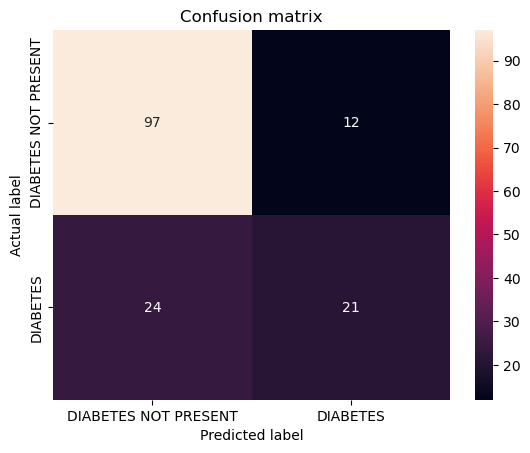

In [423]:
class_names=["DIABETES NOT PRESENT","DIABETES"]
cnf_matrix=confusion_matrix(y_test,y_pred)
sns.heatmap(cnf_matrix,annot=True,xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion matrix')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()